## 1. Importing Libraries

In [ ]:
#Importing Libraries for data analysis, visualization,dashboard, statistics and suppress warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import calendar
import warnings
warnings.filterwarnings('ignore')

## 2. Reading the data file

In [ ]:
df = pd.read_excel('/content/Data Visualisation - COM7021 - [4566] Bakery- supporting document.xlsx')

print(df.head())


        Date    City Confectionary  Units Sold  Revenue(£)  Cost(£)  Profit(£)
0 2002-11-11  London       Biscuit      1118.0      5590.0   2459.6     3130.4
1 2002-07-05  London       Biscuit       708.0      3540.0   1557.6     1982.4
2 2001-10-31  London       Biscuit      1269.0      6345.0   2791.8     3553.2
3 2004-09-13  London       Biscuit      1631.0      8155.0   3588.2     4566.8
4 2004-03-10  London       Biscuit      2240.0     11200.0   4928.0     6272.0


## 3. Checking the dataset size

In [ ]:
#Check Dataset Size
df.shape

(1001, 7)

## 4. Checking data information

In [ ]:
print(df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1001 entries, 0 to 1000
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Date           1001 non-null   datetime64[ns]
 1   City           1001 non-null   object        
 2   Confectionary  1001 non-null   object        
 3   Units Sold     996 non-null    float64       
 4   Revenue(£)     992 non-null    float64       
 5   Cost(£)        992 non-null    float64       
 6   Profit(£)      998 non-null    float64       
dtypes: datetime64[ns](1), float64(4), object(2)
memory usage: 54.9+ KB
None


## 5. Statistical Summary

In [ ]:
#Show statistical summary of all numeric columns
df.describe(include=['number'])

,Units Sold,Revenue(£),Cost(£),Profit(£)
count,996.000000,992.000000,992.000000,998.000000
mean,1633.360442,6847.601815,2820.190877,4012.076052
std,876.356045,4699.184062,2073.969135,2648.166312
min,200.000000,200.000000,40.000000,160.000000
25%,923.000000,2993.000000,1204.000000,1872.400000
50%,1530.500000,5967.000000,2456.800000,3459.000000
75%,2300.000000,9505.000000,3977.625000,5445.000000
max,4493.000000,23988.000000,10994.500000,13479.000000


## 6. Checking null values

In [ ]:
#count missing values per column
print(df.isnull().sum())

Date             0
City             0
Confectionary    0
Units Sold       5
Revenue(£)       9
Cost(£)          9
Profit(£)        3
dtype: int64


## 7. Profit Calculation

In [ ]:
# Calculating Profit before data cleaning (imputation)
total_profit=df['Profit(£)'].sum()
print("Total Profit BEFORE recalculation:", total_profit)

Total Profit BEFORE recalculation: 4004051.9


## 8. Pairplot

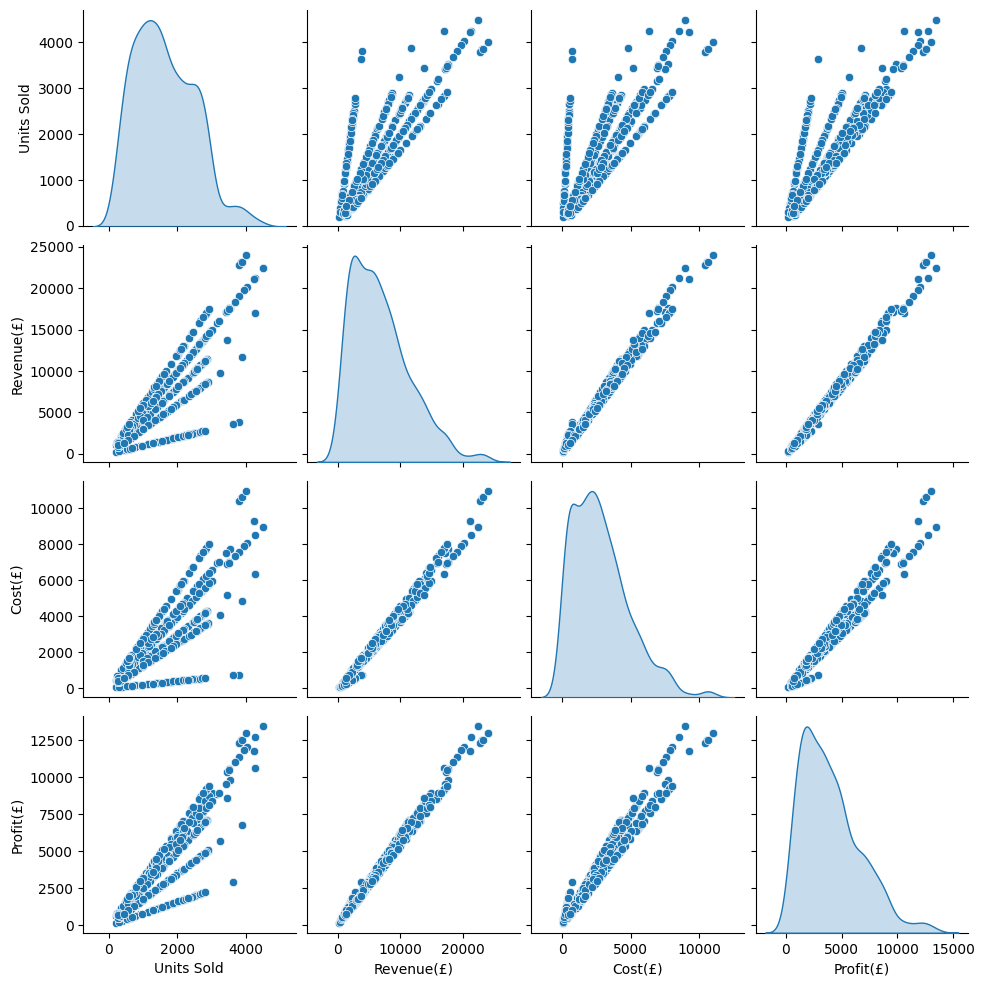

In [ ]:
#Pair Plot
sns.pairplot(df[['Units Sold','Revenue(£)','Cost(£)','Profit(£)']],diag_kind='kde')

# Save high-resolution image
plt.savefig("Pairplot", dpi=1000)
plt.show()


## 9. Outlier Detection

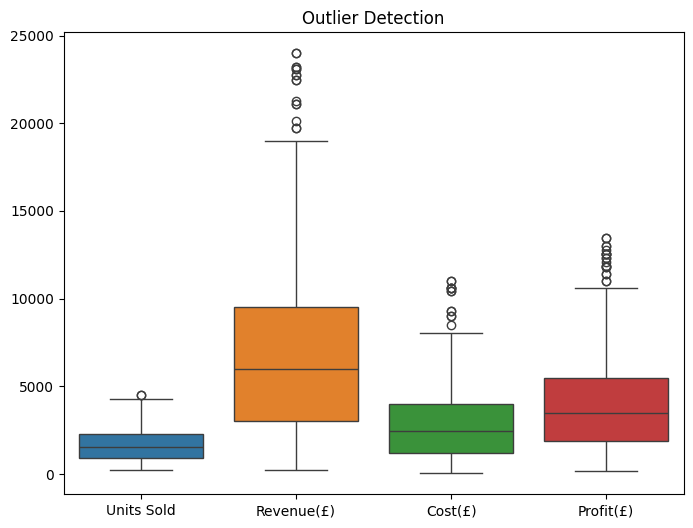

In [ ]:
#Box Plot
plt.figure(figsize=(8,6))
sns.boxplot(data=df[['Units Sold','Revenue(£)','Cost(£)','Profit(£)']])
plt.title("Outlier Detection")
# Save high-resolution image
plt.savefig("Outlier Detection", dpi=1000)
plt.show()

## 10.Median Imputation

In [ ]:
#Replace missing values with median method
df['Units Sold'].fillna(df['Units Sold'].median(), inplace=True)
df['Revenue(£)'].fillna(df['Revenue(£)'].median(), inplace=True)
df['Cost(£)'].fillna(df['Cost(£)'].median(), inplace=True)
df['Profit(£)'].fillna(df['Profit(£)'].median(), inplace=True)

## 11. Verification

In [ ]:
#Verify missing values are handled
print(df.isnull().sum())

Date             0
City             0
Confectionary    0
Units Sold       0
Revenue(£)       0
Cost(£)          0
Profit(£)        0
dtype: int64


## 12. Correlation Heatmap

Text(0.5, 1.0, 'Correlation Matrix')

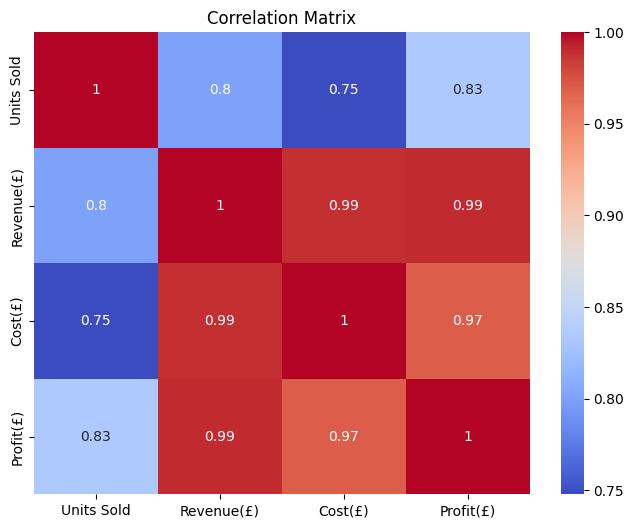

In [ ]:
#Correlation Heatmap
plt.figure(figsize=(8,6))

corr = df[['Units Sold','Revenue(£)','Cost(£)','Profit(£)']].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')

plt.title("Correlation Matrix")
# Save high-resolution image
# plt.savefig("Correlation Matrix", dpi=1000)
# plt.show()

## 13. Checking duplicate values

In [ ]:
#Check number of duplicated rows
df.duplicated().sum()

np.int64(0)

## 14. Checking the count

In [ ]:
df['Confectionary'].value_counts()

,count
Confectionary,
Caramel,345
Choclate Chunk,130
Biscuit Nut,125
Biscuit,124
Plain,112
Caramel nut,82
Caramel Nut,67
Chocolate Chunk,16


## 15. Merging of products

In [ ]:
#Merging into one category
df['Confectionary'] = df['Confectionary'].replace('Choclate Chunk', 'Chocolate Chunk')
df['Confectionary'] = df['Confectionary'].replace('Caramel nut', 'Caramel Nut')

In [ ]:
df['Confectionary'].value_counts()

,count
Confectionary,
Caramel,345
Caramel Nut,149
Chocolate Chunk,146
Biscuit Nut,125
Biscuit,124
Plain,112


## 16. Recalculate the profit after mean imputation

In [ ]:
# Recalculating Profit after data cleaning (imputation)
df['Recalculated_Profit(£)'] = df['Revenue(£)'] - df['Cost(£)']

## 17. Total profit caclulcation after median imputation

In [ ]:
total_profit_after = df['Recalculated_Profit(£)'].sum()

print("Total Profit AFTER recalculation:", total_profit_after)

Total Profit AFTER recalculation: 4026783.45


## 18. Creation of months and years column

In [ ]:
# Extracting Year and Month from the Date column
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month

In [ ]:
# Converting Month numbers to full names (e.g., 1 to January)
df['Month_Name'] = df['Month'].apply(lambda x: calendar.month_name[x])

In [ ]:
# Defining the logical order of months for plotting
month_order = list(calendar.month_name)[1:]

# Applying Categorical sorting to ensure months appear chronologically
df['Month_Name'] = pd.Categorical(df['Month_Name'],
                                  categories=month_order,
                                  ordered=True)

## 19. Data Visualisation

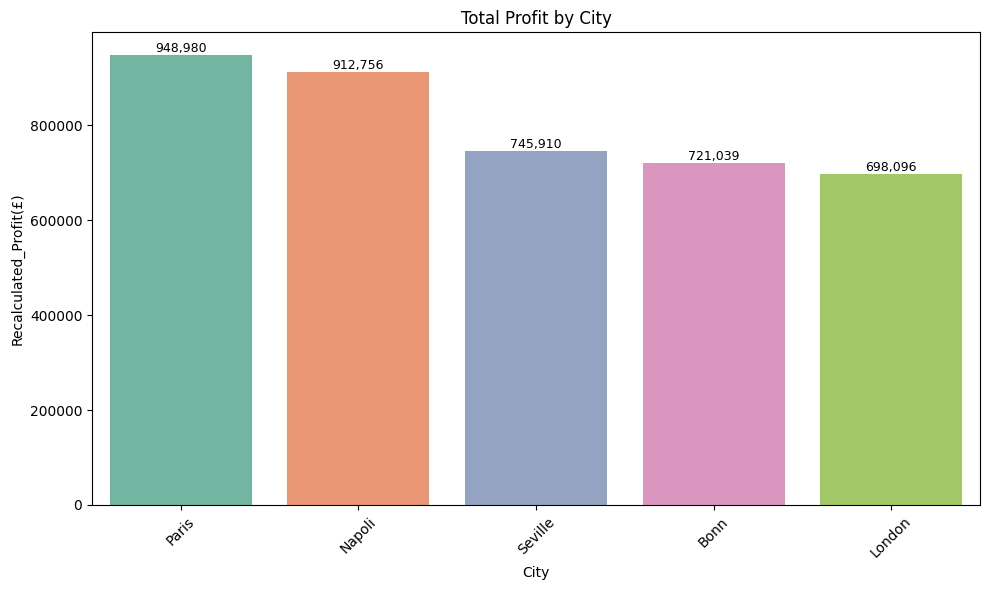

In [ ]:
# Group data by city and calculate total profit
city_profit = df.groupby('City')['Recalculated_Profit(£)'].sum().reset_index()

# Sort cities by profit in descending order
city_profit = city_profit.sort_values(by='Recalculated_Profit(£)', ascending=False)

# Create figure with specified size
plt.figure(figsize=(10,6))

# Create bar plot of profit by city
ax = sns.barplot(x='City', y='Recalculated_Profit(£)', data=city_profit, palette='Set2')

# Set plot title
plt.title("Total Profit by City")

# Rotate x-axis labels for better readability
plt.xticks(rotation=45)

# Loop through bars to add value labels on top
for p in ax.patches:
    height = p.get_height()  # Get height of each bar
    ax.text(x=p.get_x() + p.get_width()/2,
            y=height,
            s=f'{int(height):,}',  # Format number with commas
            ha='center',
            va='bottom',
            fontsize=9)

# Adjust layout to prevent clipping
plt.tight_layout()

# Save plot as high-resolution image
plt.savefig("Total profit by City", dpi=1000)

# Display the plot
plt.show()

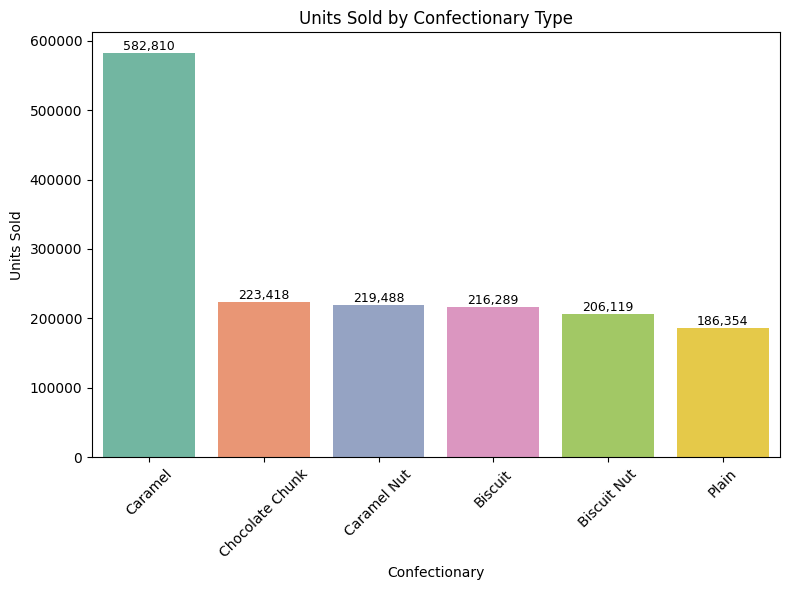

In [ ]:
# Group data by confectionary type and calculate total units sold
product_sales = df.groupby('Confectionary')['Units Sold'].sum().reset_index()

# Sort confectionary types by units sold in descending order
product_sales = product_sales.sort_values(by='Units Sold', ascending=False)

# Create figure with specified size
plt.figure(figsize=(8,6))

# Create bar plot of units sold by confectionary type
ax = sns.barplot(x='Confectionary', y='Units Sold', data=product_sales, palette='Set2')

# Set plot title
plt.title("Units Sold by Confectionary Type")

# Rotate x-axis labels for better readability
plt.xticks(rotation=45)

# Loop through bars to add value labels on top
for p in ax.patches:
    height = p.get_height()  # Get height of each bar

    ax.text(p.get_x() + p.get_width()/2,
            height,
            f'{int(height):,}',  # Format number with commas
            ha='center',
            va='bottom',
            fontsize=9)

# Adjust layout to prevent clipping
plt.tight_layout()

# Save plot as high-resolution image
plt.savefig("Units Sold by Confectionary Type", dpi=1000)

# Display the plot
plt.show()

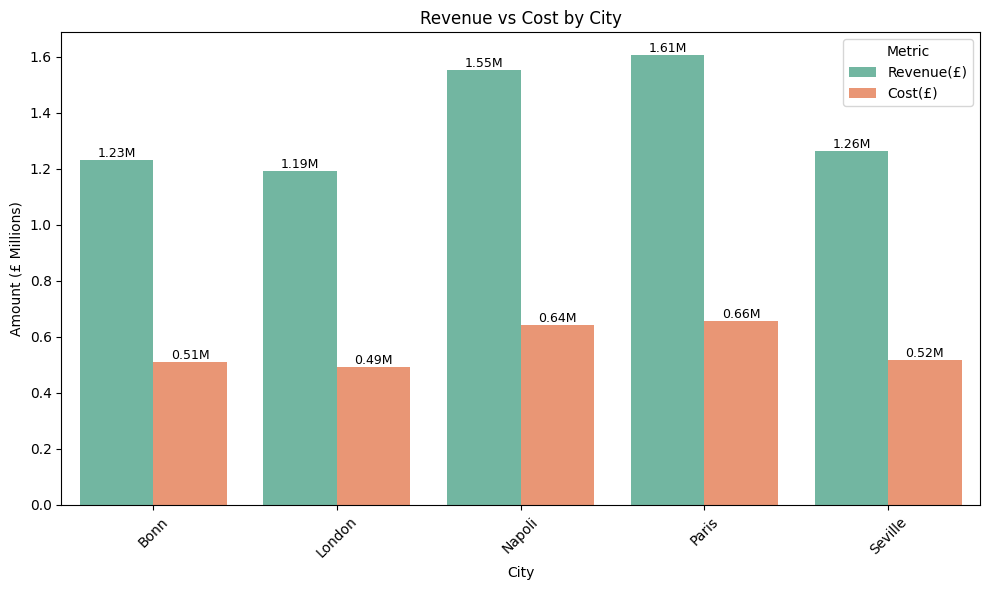

In [ ]:
# Group data by city and calculate total revenue and cost
city_finance = df.groupby('City')[['Revenue(£)','Cost(£)']].sum().reset_index()

# Reshape data from wide to long format for plotting
city_melted = city_finance.melt(id_vars='City',
                                value_vars=['Revenue(£)','Cost(£)'],
                                var_name='Metric',
                                value_name='Value')

# Convert values to millions for better readability
city_melted['Value_M'] = city_melted['Value'] / 1e6

# Create figure with specified size
plt.figure(figsize=(10,6))

# Create grouped bar plot for revenue and cost by city
ax = sns.barplot(x='City',
                 y='Value_M',
                 hue='Metric',
                 data=city_melted,
                 palette='Set2')

# Set plot title
plt.title("Revenue vs Cost by City")

# Set x-axis label
plt.xlabel("City")

# Set y-axis label
plt.ylabel("Amount (£ Millions)")

# Rotate x-axis labels for better readability
plt.xticks(rotation=45)

# Loop through bars to add value labels
for bar in ax.patches:

    height = bar.get_height()  # Get height of each bar

    if height > 0:
        ax.text(bar.get_x() + bar.get_width()/2,
                height,
                f'{height:.2f}M',  # Format value in millions
                ha='center',
                va='bottom',
                fontsize=9)

# Adjust layout to prevent clipping
plt.tight_layout()

# Save plot as high-resolution image
plt.savefig("Revenue vs Cost by City", dpi=1000)

# Display the plot
plt.show()

In [ ]:
# Create a sunburst chart showing hierarchical profit distribution
fig = px.sunburst(df,
                  path=['City','Confectionary'],  # Define hierarchy: City → Confectionary
                  values='Recalculated_Profit(£)',            # Use profit as the metric
                  title="Profit Contribution by City and Product")

# Display the interactive chart
fig.show()

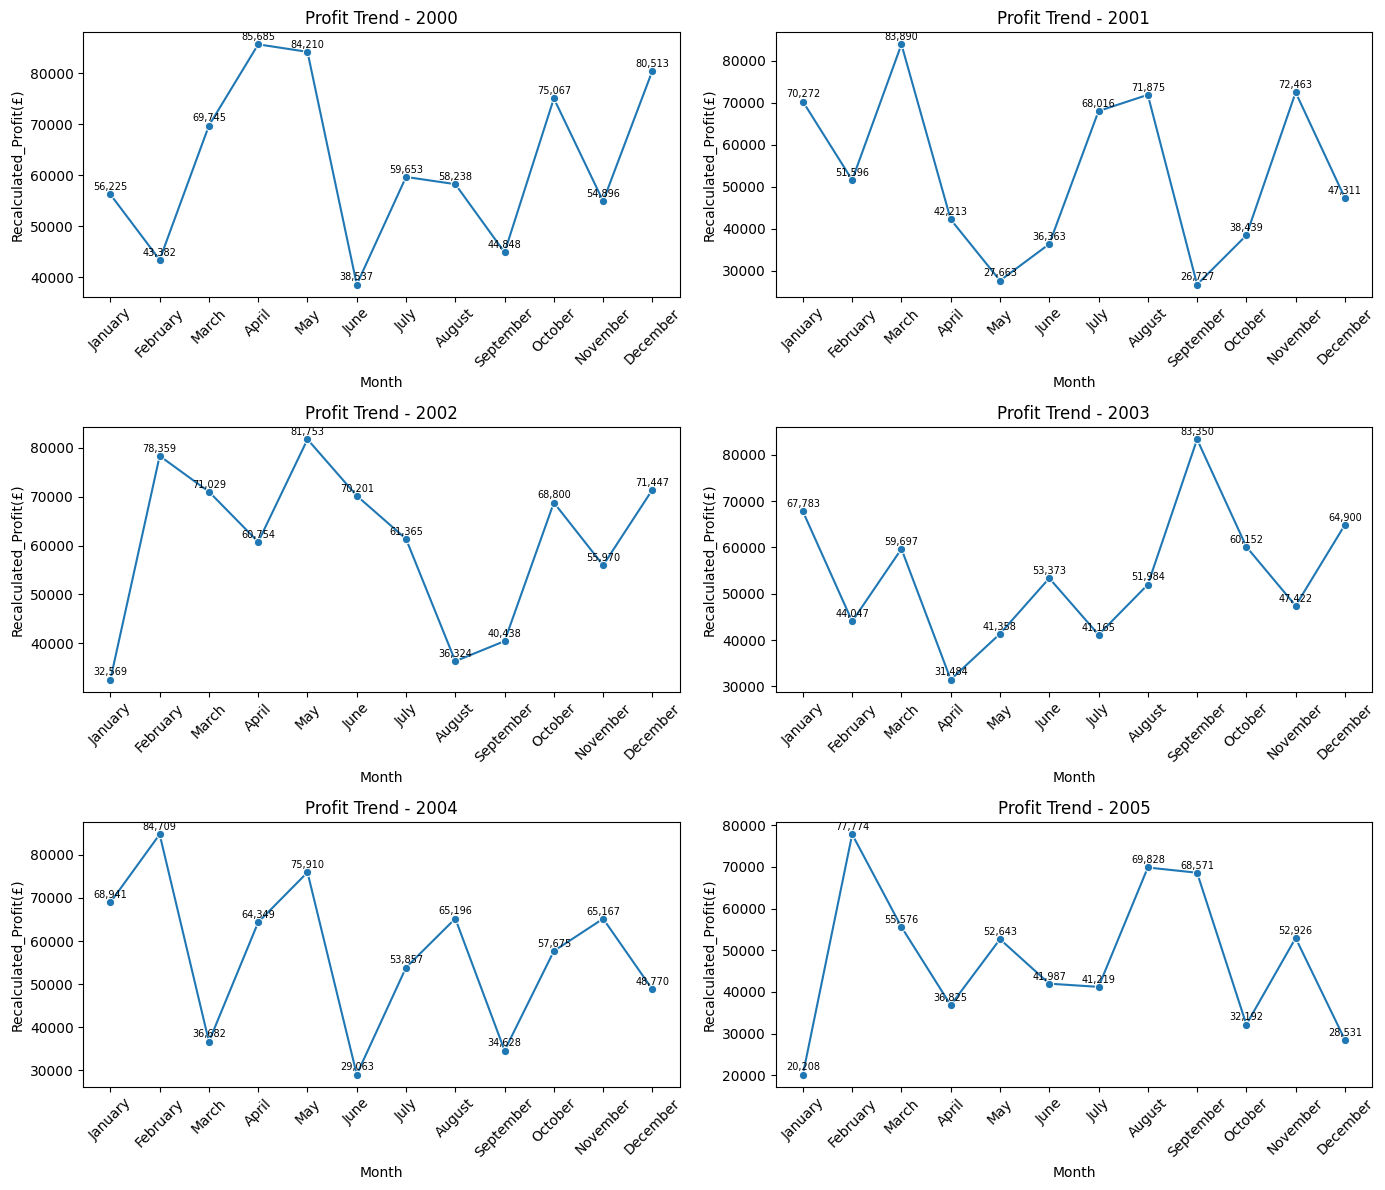

In [ ]:
# Aggregate profit by year and month
monthly = df.groupby(['Year','Month_Name'])['Recalculated_Profit(£)'].sum().reset_index()

# Get list of unique years
years = monthly['Year'].unique()

# Calculate subplot grid size (rows and columns)
rows = (len(years) // 2) + (len(years) % 2)
cols = 2

# Create subplots for each year
fig, axes = plt.subplots(rows, cols, figsize=(14, rows*4))
axes = axes.flatten()

# Loop through each year and plot monthly profit trend
for i, year in enumerate(years):

    # Filter data for current year
    data_year = monthly[monthly['Year'] == year]

    # Plot line chart for monthly profit
    sns.lineplot(
        data=data_year,
        x='Month_Name',
        y='Recalculated_Profit(£)',
        marker='o',
        ax=axes[i]
    )

    # Set subplot title
    axes[i].set_title(f"Profit Trend - {year}")

    # Set x-axis label
    axes[i].set_xlabel("Month")

    # Set y-axis label
    axes[i].set_ylabel("Recalculated_Profit(£)")

    # Rotate x-axis labels for readability
    axes[i].tick_params(axis='x', rotation=45)

    # Add annotations for each month value
    for x, y in zip(data_year['Month_Name'], data_year['Recalculated_Profit(£)']):
        axes[i].annotate(f'{y:,.0f}',
                         xy=(x, y),
                         xytext=(0, 3),   # small vertical offset
                         textcoords='offset points',
                         ha='center',
                         fontsize=7)

# Adjust layout to prevent overlap
plt.tight_layout()

# Save plot as high-resolution image
plt.savefig("Monthly Profit Trend", dpi=1000)

# Display the plot
plt.show()


In [ ]:
# Group data by year and city and calculate total profit
city_profit_year = df.groupby(['Year','City'])['Recalculated_Profit(£)'].sum().reset_index()
city_profit_year['Year_str'] = city_profit_year['Year'].astype(str)

# Create a faceted bar chart showing city-wise profit per year
fig = px.bar(city_profit_year,
             x='City',
             y='Recalculated_Profit(£)',
             color='City',
             facet_col='Year',
             facet_col_wrap=3,
             custom_data=['Year_str'],
             title="City-wise Profit (£) Performance by Year",
             labels={'Recalculated_Profit(£)':'Profit (£)'})
fig.update_traces(
    hovertemplate=
    'City: %{x}<br>' +
    'Year: %{customdata[0]}<br>' +
    'Profit: £%{y:,.0f}<extra></extra>'
)

# Display the interactive chart
fig.show()

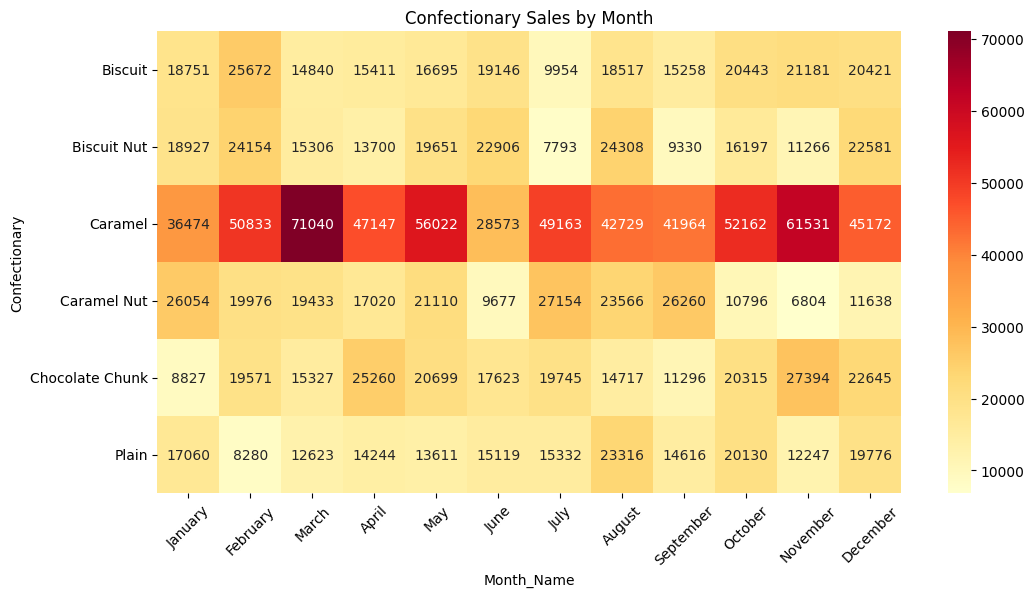

In [ ]:
# Create pivot table for units sold by confectionary and month
heat = df.pivot_table(
    index='Confectionary',
    columns='Month_Name',
    values='Units Sold',
    aggfunc='sum'
)

# Create figure with specified size
plt.figure(figsize=(12,6))

# Plot heatmap of sales data
sns.heatmap(
    heat,
    annot=True,
    cmap="YlOrRd",
    fmt=".0f"
)

# Set plot title
plt.title("Confectionary Sales by Month")

# Rotate x-axis labels for better readability
plt.xticks(rotation=45)

# Save plot as high-resolution image
plt.savefig("Confectionary Sales by Month Heatmap", dpi=1000)

# Display the plot
plt.show()

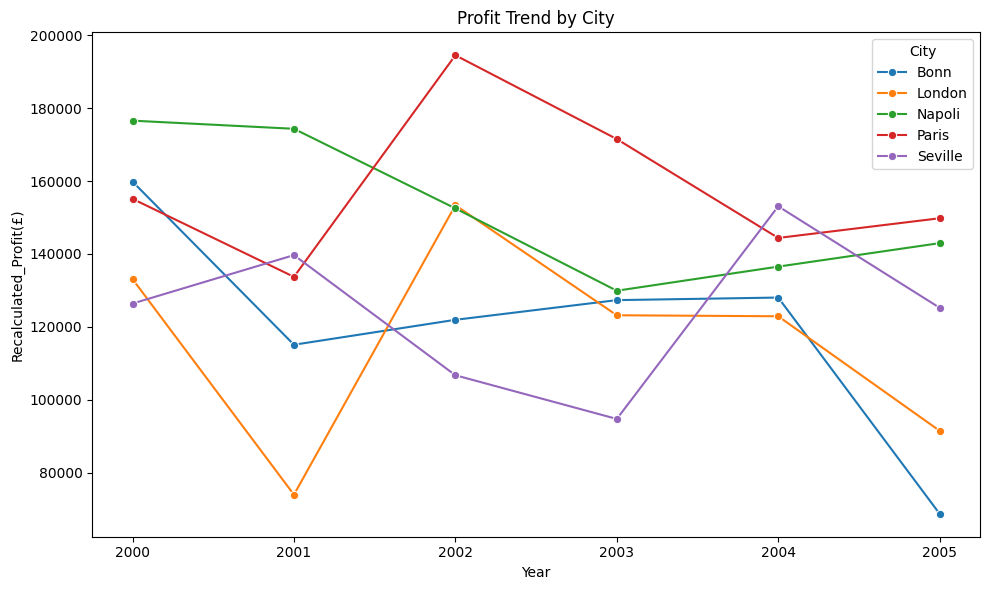

In [ ]:
# Group data by year and city to calculate total profit
city_trend = df.groupby(['Year','City'])['Recalculated_Profit(£)'].sum().reset_index()

# Create figure with specified size
plt.figure(figsize=(10,6))

# Plot profit trend by city over years
ax = sns.lineplot(
    data=city_trend,
    x='Year',
    y='Recalculated_Profit(£)',
    hue='City',
    marker='o'
)

# Set plot title
plt.title("Profit Trend by City")

# Adjust layout to prevent overlap
plt.tight_layout()

# Save plot as high-resolution image
plt.savefig("Profit Trend by City", dpi=1000)

# Display the plot
plt.show()

## 20. Dashboard

In [ ]:
# DATA PREP
df['Year'] = pd.to_datetime(df['Date']).dt.year

# Calculate overall KPIs
total_revenue = df['Revenue(£)'].sum()
total_cost = df['Cost(£)'].sum()
total_profit = df['Recalculated_Profit(£)'].sum()

city_fin = df.groupby('City')[['Revenue(£)','Cost(£)','Recalculated_Profit(£)']].sum().reset_index()
profit_product = df.groupby('Confectionary')['Recalculated_Profit(£)'].sum().reset_index()
units_product = df.groupby('Confectionary')['Units Sold'].sum().reset_index()
yearly = df.groupby('Year')[['Revenue(£)','Cost(£)','Recalculated_Profit(£)']].sum().reset_index()
monthly = df.groupby('Month_Name')['Recalculated_Profit(£)'].sum().reset_index()


# SUBPLOTS (CLEAN LAYOUT)

# Create dashboard layout with multiple subplot types
fig = make_subplots(
    rows=3, cols=2,
    specs=[
        [{"type": "xy"}, {"type": "domain"}],
        [{"type": "xy"}, {"type": "xy"}],
        [{"type": "xy"}, {"type": "xy"}]
    ],
    horizontal_spacing=0.17,
    vertical_spacing=0.15,
    subplot_titles=[
        "Revenue / Cost / Profit by City",
        "Profit Contribution by Product",
        "Yearly Financial Trend",
        "Units Sold by Product",
        "Monthly Profit Pattern",
        "Profit Margin by City"
    ]
)


# 1. CITY FINANCIAL COMPARISON
# Add revenue bars by city
fig.add_trace(go.Bar(
    x=city_fin['City'],
    y=city_fin['Revenue(£)'],
    name='Revenue',
    marker_color='#4CAF50'
), row=1, col=1)

# Add cost bars by city
fig.add_trace(go.Bar(
    x=city_fin['City'],
    y=city_fin['Cost(£)'],
    name='Cost',
    marker_color='#F44336'
), row=1, col=1)

# Add profit bars by city
fig.add_trace(go.Bar(
    x=city_fin['City'],
    y=city_fin['Recalculated_Profit(£)'],
    name='Profit',
    marker_color='#2196F3'
), row=1, col=1)

fig.update_xaxes(title_text="City", row=1, col=1)
fig.update_yaxes(title_text="Amount (£)", row=1, col=1)

# fig.update_traces(
#     selector=dict(row=1, col=1),
#     hovertemplate=
#     'City: %{x}<br>' +
#     '%{fullData.name}: £%{y:,.0f}<extra></extra>' +
#     'Value: £%{y:,.0f}<extra></extra>'
# )

fig.update_traces(
    selector=dict(type='bar'),
    hovertemplate=
    'City: %{x}<br>' +
    '%{fullData.name}: £%{y:,.0f}<extra></extra>'
)

# 2. DONUT CHART (FIXED)
# Create donut chart for profit contribution by product
fig.add_trace(go.Pie(
    labels=profit_product['Confectionary'],
    values=profit_product['Recalculated_Profit(£)'],
    hole=0.5,
    textinfo='percent+label',
    showlegend=False
), row=1, col=2)

fig.update_traces(
    selector=dict(type='pie'),
    hovertemplate=
    'Product: %{label}<br>' +
    'Profit: £%{value:,.0f}<br>' +
    'Share: %{percent}<extra></extra>'
)

# 3. YEARLY TREND
# Plot revenue trend over years
fig.add_trace(go.Scatter(
    x=yearly['Year'],
    y=yearly['Revenue(£)'],
    mode='lines+markers',
    name='Revenue'
), row=2, col=1)

# Plot cost trend over years
fig.add_trace(go.Scatter(
    x=yearly['Year'],
    y=yearly['Cost(£)'],
    mode='lines+markers',
    name='Cost'
), row=2, col=1)

# Plot profit trend over years
fig.add_trace(go.Scatter(
    x=yearly['Year'],
    y=yearly['Recalculated_Profit(£)'],
    mode='lines+markers',
    name='Profit'
), row=2, col=1)

fig.update_xaxes(title_text="Year", row=2, col=1)
fig.update_yaxes(title_text="Amount (£)", row=2, col=1)

# fig.update_traces(
#     selector=dict(row=2, col=1),
#     hovertemplate=
#     'Year: %{x}<br>' +
#     '%{fullData.name}: £%{y:,.0f}<extra></extra>'
# )

fig.update_traces(
    selector=dict(type='scatter'),
    hovertemplate=
    'Year: %{x}<br>' +
    '%{fullData.name}: £%{y:,.0f}<extra></extra>'
)

# 4. UNITS SOLD (FIXED LABEL CUT-OFF)
# Horizontal bar chart for units sold by product
fig.add_trace(go.Bar(
    y=units_product['Confectionary'],
    x=units_product['Units Sold'],
    orientation='h',
    marker_color='#9C27B0',
    hovertemplate='Product: %{y}<br>Units Sold: %{x:,.0f}<extra></extra>',
    text=[f"{int(v/1000)}K" for v in units_product['Units Sold']],
    textposition='auto',
    cliponaxis=False,
    showlegend=False
), row=2, col=2)

fig.update_xaxes(title_text="Units Sold", row=2, col=2)
fig.update_yaxes(title_text="Product", row=2, col=2)


# 5. MONTHLY PROFIT
# Area chart for monthly profit trend
fig.add_trace(go.Scatter(
    x=monthly['Month_Name'],
    y=monthly['Recalculated_Profit(£)'],
    fill='tozeroy',
    mode='lines',
    line=dict(color='#FF9800'),
    hovertemplate='Month: %{x}<br>Profit: £%{y:,.0f}<extra></extra>',
    showlegend=False
), row=3, col=1)

fig.update_xaxes(title_text="Month", row=3, col=1)
fig.update_yaxes(title_text="Profit (£)", row=3, col=1)


# 6. TOP CITIES BY PROFIT
# Sort cities by profit
top_city = city_fin.sort_values('Recalculated_Profit(£)', ascending=True)

fig.update_xaxes(title_text="Profit (£)", row=3, col=2)
fig.update_yaxes(title_text="City", row=3, col=2)

# Horizontal bar chart for city profit
fig.add_trace(go.Bar(
    y=top_city['City'],
    x=top_city['Recalculated_Profit(£)'],
    orientation='h',
    marker_color='#00BCD4',
    hovertemplate='City: %{y}<br>Profit: £%{x:,.0f}<extra></extra>',
    text=[f"{v/1e6:.2f}M" for v in top_city['Recalculated_Profit(£)']],
    textposition='auto',
    cliponaxis=False,
    showlegend=False
), row=3, col=2)


# GRID STYLING
# Style city financial subplot
fig.update_xaxes(showgrid=False, row=1, col=1)
fig.update_yaxes(showgrid=True, gridcolor='rgba(0,0,0,0.15)', row=1, col=1)

# Style donut chart subplot
fig.update_xaxes(showgrid=False, row=1, col=2)
fig.update_yaxes(showgrid=False, row=1, col=2)

# Style yearly trend subplot
fig.update_xaxes(showgrid=True, gridcolor='rgba(0,0,0,0.2)', row=2, col=1)
fig.update_yaxes(showgrid=True, gridcolor='rgba(0,0,0,0.2)', row=2, col=1)

# Style units sold subplot
fig.update_xaxes(showgrid=False, row=2, col=2)
fig.update_yaxes(showgrid=True, gridcolor='rgba(0,0,0,0.12)', row=2, col=2)

# Style monthly profit subplot
fig.update_xaxes(showgrid=True, gridcolor='rgba(0,0,0,0.18)', row=3, col=1)
fig.update_yaxes(showgrid=True, gridcolor='rgba(0,0,0,0.18)', row=3, col=1)

# Style city profit subplot
fig.update_xaxes(showgrid=True, gridcolor='rgba(0,0,0,0.12)', row=3, col=2)
fig.update_yaxes(showgrid=False, row=3, col=2)

# LAYOUT FIXES (IMPORTANT)
# Configure overall dashboard layout
fig.update_layout(
    height=1500,
    width=1200,
    template='plotly_white',
    barmode='group',

    # Center main title
    title={
        'text': "European Bakery Sales Dashboard",
        'x': 0.5,
        'xanchor': 'center'
    },

    # Prevent label clipping
    margin=dict(l=80, r=120, t=140, b=80),

    # Legend positioning
    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=1.08,
        xanchor="center",
        x=0.5
    )
)


# SUBPLOT BORDERS (CLEAN BI STYLE)
# Function to add borders around subplots
def add_subplot_border(fig, row, col):
    fig.update_xaxes(
        showline=True,
        linewidth=1,
        linecolor="darkgrey",
        mirror=True,
        row=row,
        col=col
    )

    fig.update_yaxes(
        showline=True,
        linewidth=1,
        linecolor="darkgrey",
        mirror=True,
        row=row,
        col=col
    )

# Apply borders to all subplots
add_subplot_border(fig, 1, 1)
add_subplot_border(fig, 1, 2)
add_subplot_border(fig, 2, 1)
add_subplot_border(fig, 2, 2)
add_subplot_border(fig, 3, 1)
add_subplot_border(fig, 3, 2)


# KPI ROW (CLEAN FIXED POSITION)
# Add revenue KPI
fig.add_annotation(text=f"<b>Revenue:</b> £{total_revenue/1e6:.2f}M",
                   x=0.15, y=1.16, xref='paper', yref='paper',
                   showarrow=False)

# Add cost KPI
fig.add_annotation(text=f"<b>Cost:</b> £{total_cost/1e6:.2f}M",
                   x=0.5, y=1.16, xref='paper', yref='paper',
                   showarrow=False)

# Add profit KPI
fig.add_annotation(text=f"<b>Profit:</b> £{total_profit/1e6:.2f}M",
                   x=0.85, y=1.16, xref='paper', yref='paper',
                   showarrow=False)


# Display final dashboard
fig.show()